# Predicting Song Hits from Audio Characteristics
### DSC 148 — Course Project
**Daniel Phan** \
**Rachel Sakamoto**

**Research question:** *What audio characteristics make a song likely to become a hit?*

To answer our question, we decided to frame this as a **binary classification** problem on the Spotify 1M Tracks dataset. \
We felt that saying a song is a "hit" can be ambiguous, so we decided that a track is labeled a **hit** if its `popularity` is in the top 10% of all tracks.

In order to answer our research question, we will be utilizing 4 models to visualize and compare them.
| Role | Model | Rationale |
|---|---|---|
| Baseline 1 | Majority Class Predictor | Minimum performance bar |
| Baseline 2 | Logistic Regression | Simple, standard linear model |
| Model 1 | Random Forest | Nonlinear, feature interactions |
| Model 2 | XGBoost | State-of-the-art on tabular data |

---

## 0. Setup

In [23]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             precision_score, recall_score, confusion_matrix,
                             roc_curve, precision_recall_curve, average_precision_score,
                             classification_report)
import xgboost as xgb

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
RNG = 42
os.makedirs("figures", exist_ok=True)
results = {}   # collect metrics for the report

## 1. Dataset

The [Spotify 1 Million Tracks](https://www.kaggle.com/datasets/amitanshjoshi/spotify-1million-tracks) 
dataset contains ~1.16M tracks with audio features computed by Spotify
(danceability, energy, valence, etc.), plus a `popularity` score (0–100).

> **Run-once cell.** If you already have the dataset cached locally, set `DATA_PATH`
> in the next cell to that file and skip this download.

In [24]:
import kagglehub
path = kagglehub.dataset_download("amitanshjoshi/spotify-1million-tracks")
print("Path to dataset files:", path)
print(os.listdir(path))

Path to dataset files: C:\Users\danie\.cache\kagglehub\datasets\amitanshjoshi\spotify-1million-tracks\versions\1
['spotify_data.csv']


In [25]:
# Point this at the CSV. By default uses the kagglehub cache from the cell above.
DATA_PATH = os.path.join(path, "spotify_data.csv")

df = pd.read_csv(DATA_PATH)
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
print("Raw shape:", df.shape)
df.head()

Raw shape: (1159764, 19)


,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,Jason Mraz,I Won't Give Up,53QF56cjZA9RTuuMZDrSA6,68,2012,acoustic,0.483,0.303,4,-10.058,1,0.0429,0.6940,0.000000,0.1150,0.139,133.406,240166,3
1,Jason Mraz,93 Million Miles,1s8tP3jP4GZcyHDsjvw218,50,2012,acoustic,0.572,0.454,3,-10.286,1,0.0258,0.4770,0.000014,0.0974,0.515,140.182,216387,4
2,Joshua Hyslop,Do Not Let Me Go,7BRCa8MPiyuvr2VU3O9W0F,57,2012,acoustic,0.409,0.234,3,-13.711,1,0.0323,0.3380,0.000050,0.0895,0.145,139.832,158960,4
3,Boyce Avenue,Fast Car,63wsZUhUZLlh1OsyrZq7sz,58,2012,acoustic,0.392,0.251,10,-9.845,1,0.0363,0.8070,0.000000,0.0797,0.508,204.961,304293,4
4,Andrew Belle,Sky's Still Blue,6nXIYClvJAfi6ujLiKqEq8,54,2012,acoustic,0.430,0.791,6,-5.419,0,0.0302,0.0726,0.019300,0.1100,0.217,171.864,244320,4


### 1.1 Cleaning

In [26]:
AUDIO_FEATURES = ["danceability", "energy", "key", "loudness", "mode",
                  "speechiness", "acousticness", "instrumentalness",
                  "liveness", "valence", "tempo", "duration_ms", "time_signature"]

print("Duplicate track_ids:", df.duplicated(subset=["track_id"]).sum())
df = df.drop_duplicates(subset=["track_id"]).reset_index(drop=True)
df = df.dropna(subset=AUDIO_FEATURES + ["popularity"]).reset_index(drop=True)
print("Clean shape:", df.shape)
df[AUDIO_FEATURES + ["popularity", "year"]].describe().round(3)

Duplicate track_ids: 0
Clean shape: (1159764, 19)


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,popularity,year
count,1159764.000,1159764.000,1159764.000,1159764.000,1159764.000,1159764.000,1159764.000,1159764.000,1159764.000,1159764.000,1159764.000,1159764.000,1159764.000,1159764.000,1159764.000
mean,0.537,0.640,5.288,-8.981,0.635,0.093,0.322,0.252,0.223,0.456,121.377,249561.781,3.886,18.383,2011.955
std,0.184,0.271,3.555,5.682,0.482,0.127,0.355,0.365,0.201,0.269,29.780,149426.165,0.468,15.886,6.804
min,0.000,0.000,0.000,-58.100,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2073.000,0.000,0.000,2000.000
25%,0.413,0.454,2.000,-10.829,0.000,0.037,0.006,0.000,0.098,0.226,98.797,181091.000,4.000,5.000,2006.000
50%,0.550,0.694,5.000,-7.450,1.000,0.051,0.147,0.002,0.134,0.438,121.931,225744.000,4.000,15.000,2012.000
75%,0.677,0.873,8.000,-5.276,1.000,0.089,0.640,0.614,0.292,0.674,139.903,286913.500,4.000,29.000,2018.000
max,0.993,1.000,11.000,6.172,1.000,0.971,0.996,1.000,1.000,1.000,249.993,6000495.000,5.000,100.000,2023.000


### 1.2 Exploratory Data Analysis

#### Defining a "hit"
There isn't a definitive defintion of a hit label, so we derived one from `popularity`.
Most tracks have low popularity, so we treated the **top 10%** (90th percentile) as hits. \
This gave us a clear, imbalanced classification target that reflected the
real-world rarity of hit songs.

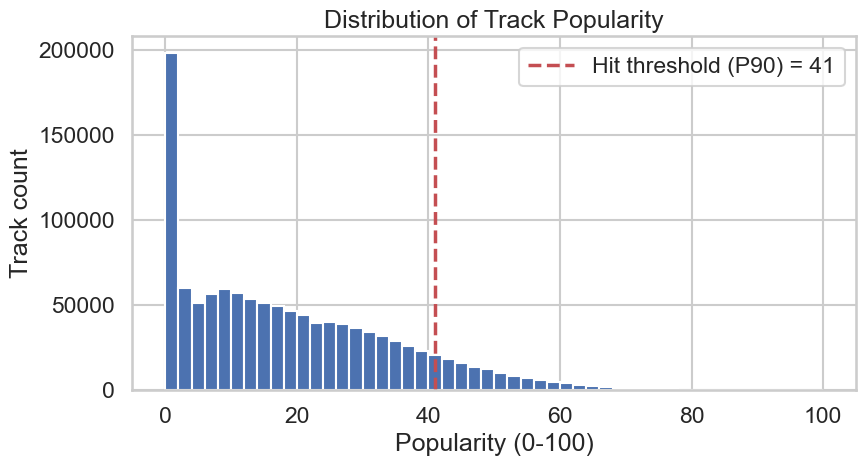

threshold=41.0  hit_rate=10.593%  #hits=122,857  #non-hits=1,036,907


In [27]:
HIT_PERCENTILE = 90
thr = np.percentile(df["popularity"], HIT_PERCENTILE)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["popularity"], bins=50, color="#4C72B0", edgecolor="white")
ax.axvline(thr, color="#C44E52", lw=2.5, ls="--",
           label=f"Hit threshold (P{HIT_PERCENTILE}) = {thr:.0f}")
ax.set_xlabel("Popularity (0-100)"); ax.set_ylabel("Track count")
ax.set_title("Distribution of Track Popularity"); ax.legend()
fig.tight_layout(); fig.savefig("figures/01_popularity_dist.png", dpi=150); plt.show()

df["is_hit"] = (df["popularity"] >= thr).astype(int)
hit_rate = df["is_hit"].mean()
print(f"threshold={thr:.1f}  hit_rate={hit_rate:.3%}  "
      f"#hits={df['is_hit'].sum():,}  #non-hits={(len(df)-df['is_hit'].sum()):,}")
results.update(hit_threshold=float(thr), hit_rate=float(hit_rate), n_total=int(len(df)))

#### Correlation structure

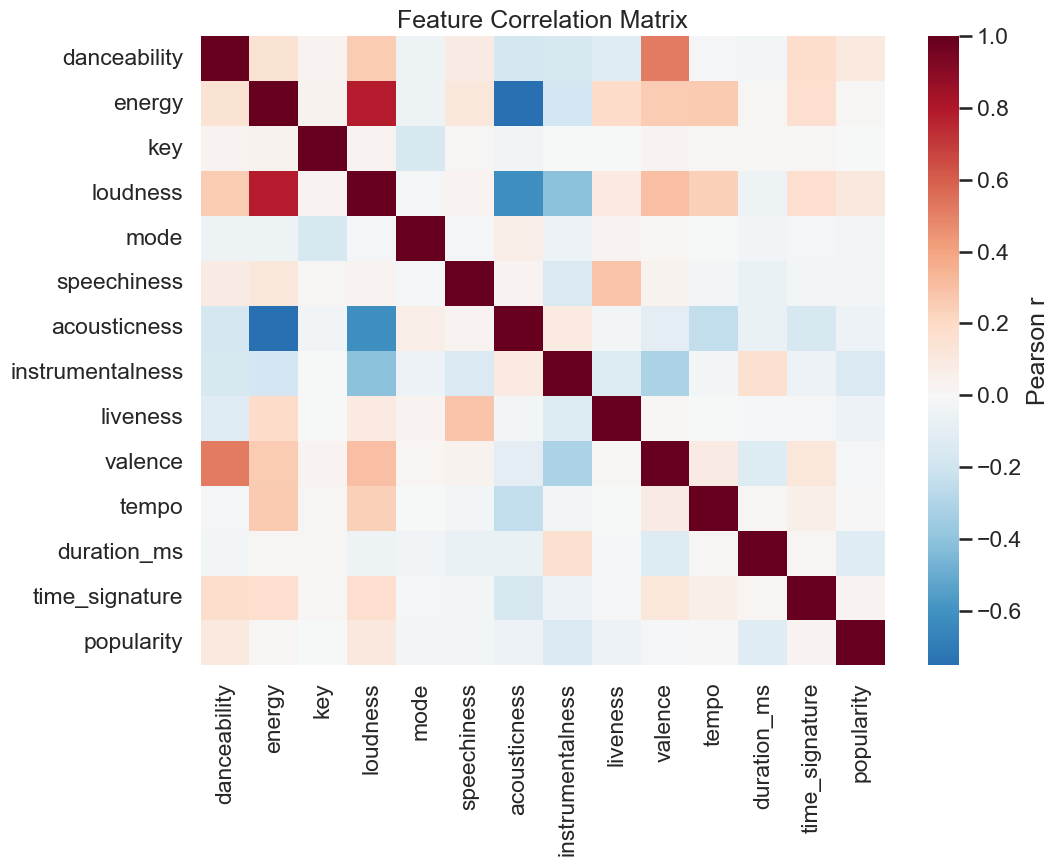

instrumentalness   -0.153
duration_ms        -0.118
loudness            0.104
danceability        0.099
acousticness       -0.059
liveness           -0.057
time_signature      0.031
speechiness        -0.025
mode               -0.024
valence            -0.018
energy              0.009
tempo               0.003
key                 0.000
Name: popularity, dtype: float64

In [28]:
corr = df[AUDIO_FEATURES + ["popularity"]].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, ax=ax, cbar_kws={"label": "Pearson r"})
ax.set_title("Feature Correlation Matrix")
fig.tight_layout(); fig.savefig("figures/02_corr_heatmap.png", dpi=150); plt.show()

corr["popularity"].drop("popularity").sort_values(key=abs, ascending=False).round(3)

#### How do hits differ from non-hits?

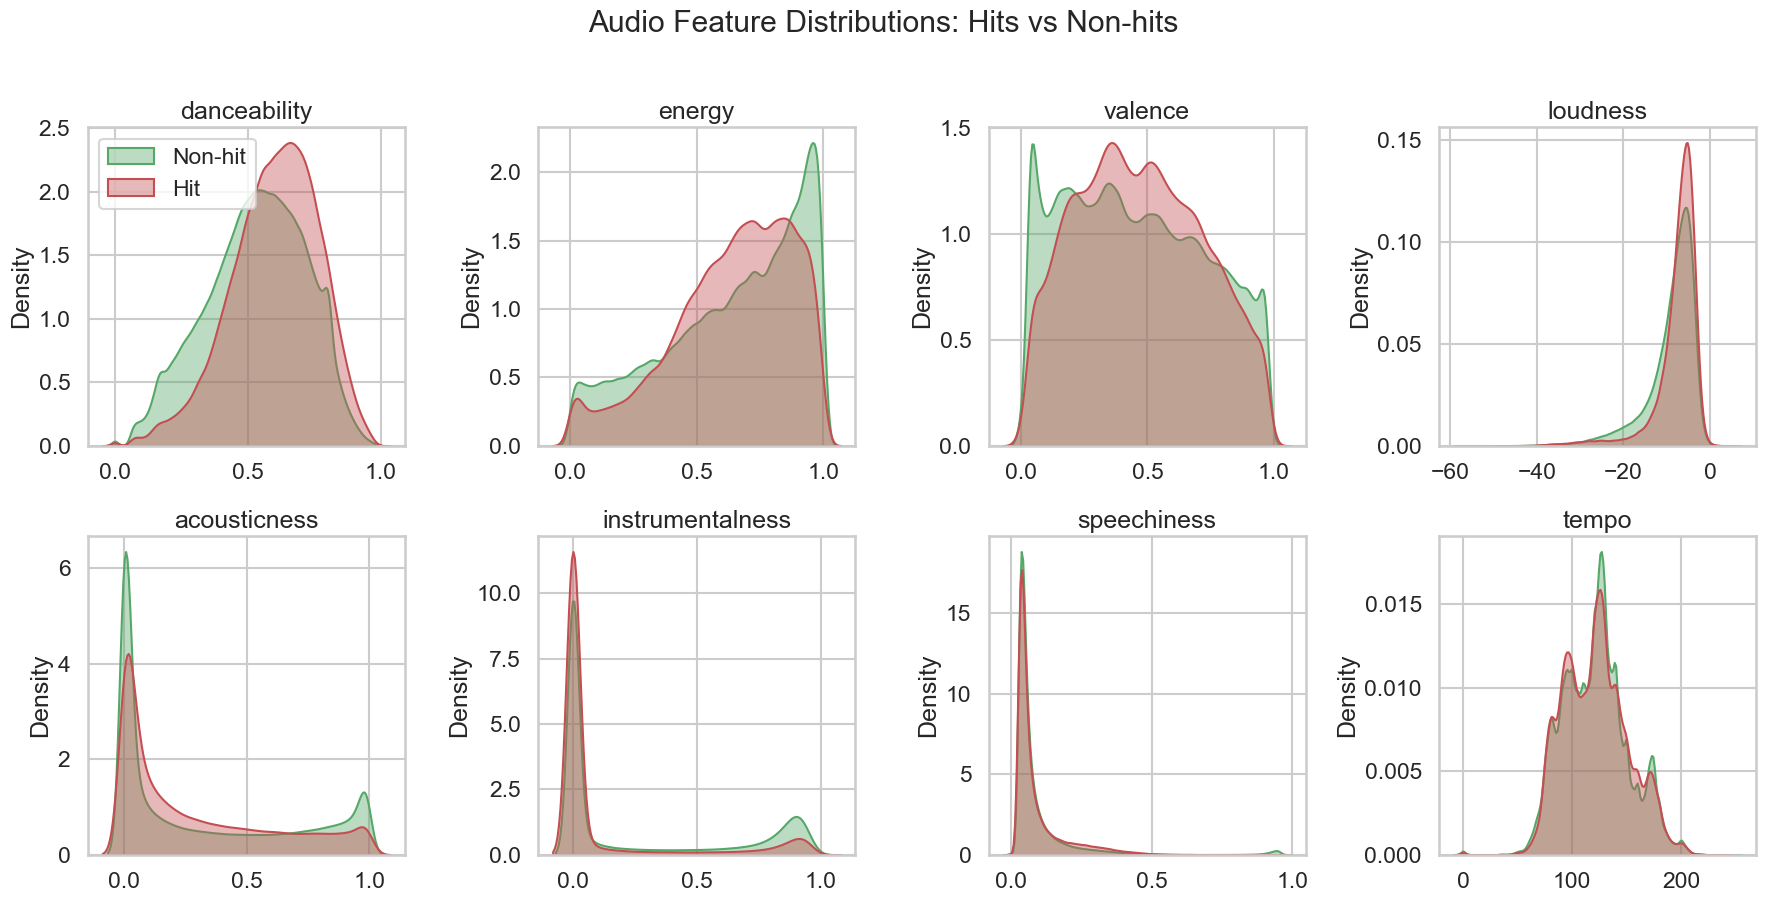

In [7]:
compare_feats = ["danceability", "energy", "valence", "loudness",
                 "acousticness", "instrumentalness", "speechiness", "tempo"]
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, feat in zip(axes.ravel(), compare_feats):
    for label, color in [(0, "#55A868"), (1, "#C44E52")]:
        sns.kdeplot(df.loc[df["is_hit"] == label, feat], ax=ax, fill=True,
                    alpha=0.4, color=color, label="Hit" if label else "Non-hit")
    ax.set_title(feat); ax.set_xlabel("")
axes.ravel()[0].legend()
fig.suptitle("Audio Feature Distributions: Hits vs Non-hits", y=1.01)
fig.tight_layout(); fig.savefig("figures/03_hit_vs_nonhit.png", dpi=150); plt.show()

In [8]:
group_means = df.groupby("is_hit")[compare_feats].mean().T
group_means.columns = ["non_hit_mean", "hit_mean"]
group_means["abs_diff"] = (group_means["hit_mean"] - group_means["non_hit_mean"]).abs()
group_means = group_means.sort_values("abs_diff", ascending=False)
group_means.to_csv("figures/table_feature_means.csv")
group_means.round(3)

,non_hit_mean,hit_mean,abs_diff
loudness,-9.128,-7.745,1.383
instrumentalness,0.268,0.123,0.145
tempo,121.363,121.493,0.130
danceability,0.530,0.600,0.069
acousticness,0.325,0.289,0.036
valence,0.454,0.470,0.016
energy,0.640,0.637,0.003
speechiness,0.093,0.091,0.002


#### Popularity over time

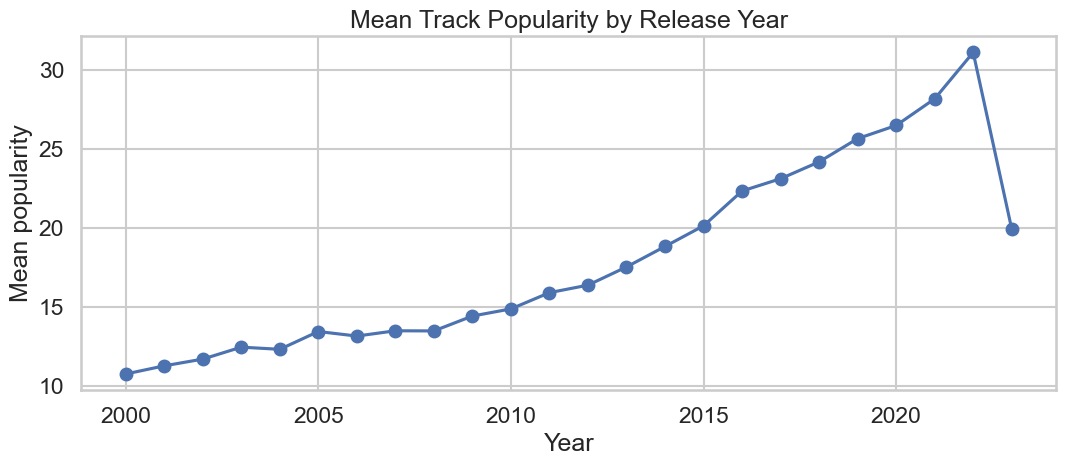

In [9]:
year_pop = df.groupby("year")["popularity"].mean()
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(year_pop.index, year_pop.values, marker="o", color="#4C72B0")
ax.set_xlabel("Year"); ax.set_ylabel("Mean popularity")
ax.set_title("Mean Track Popularity by Release Year")
fig.tight_layout(); fig.savefig("figures/04_popularity_by_year.png", dpi=150); plt.show()

## 2. Predictive Task 

**Task:** Given a track's audio characteristics, predict whether it is a hit
(`is_hit = 1`, top 10% popularity) or not.

**Evaluation.** Because the classes are imbalanced (~10% positives), accuracy alone
is misleading. We therefore reported **F1, ROC-AUC, and PR-AUC** alongside accuracy, \
and treated **F1 / PR-AUC** as the primary metrics.

**Baselines.**
- *Majority Class Predictor* — always predicts non-hit; defines the floor.
- *Logistic Regression* — assumes hit probability is a linear function of (scaled) features.

Audio features interact nonlinearly (e.g. high energy helps only when danceability is also high). 
Logistic regression cannot capture such interactions, but Random Forest and XGBoost can.

It is important to note that all 13 audio characteristics plus `year` as release-era context.
We deliberately excluded `artist_name`/`genre` so the model can focus answering the *audio* question.

In [10]:
FEATURES = AUDIO_FEATURES + ["year"]
X = df[FEATURES].copy()
y = df["is_hit"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RNG)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train hit rate:", y_train.mean().round(4), " Test hit rate:", y_test.mean().round(4))

Train: (927811, 14)  Test: (231953, 14)
Train hit rate: 0.1059  Test hit rate: 0.1059


In [11]:
def best_threshold(y_true, y_prob):
    """Pick the probability cutoff that maximizes F1 (better under imbalance)."""
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    return float(thr[np.argmax(f1[:-1])])

def evaluate(name, y_true, y_pred, y_prob=None):
    m = {"accuracy": accuracy_score(y_true, y_pred),
         "precision": precision_score(y_true, y_pred, zero_division=0),
         "recall": recall_score(y_true, y_pred, zero_division=0),
         "f1": f1_score(y_true, y_pred, zero_division=0)}
    if y_prob is not None:
        m["roc_auc"] = roc_auc_score(y_true, y_prob)
        m["pr_auc"] = average_precision_score(y_true, y_prob)
    results.setdefault("models", {})[name] = m
    print(f"[{name}]  " + "  ".join(f"{k}={v:.4f}" for k, v in m.items()))
    return m

## 3. Model

We trained the two baselines and two tree ensembles below. For the tree models we also
tuned the decision threshold on the training set through \
the PR curve instead of using the default 0.5, since the positive class is rare. `class_weight="balanced"` /
`scale_pos_weight` further counteract imbalance.

### 3.1 Baseline 1 — Majority Class Predictor

In [12]:
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
evaluate("Majority Class", y_test, dummy.predict(X_test),
         dummy.predict_proba(X_test)[:, 1]);

[Majority Class]  accuracy=0.8941  precision=0.0000  recall=0.0000  f1=0.0000  roc_auc=0.5000  pr_auc=0.1059


### 3.2 Baseline 2 — Logistic Regression

In [13]:
logit = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RNG)),
]).fit(X_train, y_train)
lprob = logit.predict_proba(X_test)[:, 1]
evaluate("Logistic Regression", y_test, logit.predict(X_test), lprob);

[Logistic Regression]  accuracy=0.6825  precision=0.2087  recall=0.7152  f1=0.3231  roc_auc=0.7676  pr_auc=0.3041


### 3.3 Model 1 — Random Forest

In [14]:
rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                            class_weight="balanced", n_jobs=-1, random_state=RNG)
rf.fit(X_train, y_train)
rprob = rf.predict_proba(X_test)[:, 1]
rf_t = best_threshold(y_train, rf.predict_proba(X_train)[:, 1])
print("RF tuned threshold:", round(rf_t, 3))
evaluate("Random Forest", y_test, (rprob >= rf_t).astype(int), rprob);

RF tuned threshold: 0.527
[Random Forest]  accuracy=0.8987  precision=0.5800  recall=0.1588  f1=0.2493  roc_auc=0.8199  pr_auc=0.3910


### 3.4 Model 2 — XGBoost

In [15]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
xgb_clf = xgb.XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos,
    eval_metric="logloss", tree_method="hist", n_jobs=-1, random_state=RNG)
xgb_clf.fit(X_train, y_train)
xprob = xgb_clf.predict_proba(X_test)[:, 1]
xgb_t = best_threshold(y_train, xgb_clf.predict_proba(X_train)[:, 1])
print("XGB tuned threshold:", round(xgb_t, 3))
xp = (xprob >= xgb_t).astype(int)
evaluate("XGBoost", y_test, xp, xprob);

XGB tuned threshold: 0.691
[XGBoost]  accuracy=0.8549  precision=0.3650  recall=0.5003  f1=0.4221  roc_auc=0.8204  pr_auc=0.3856


## 4. Literature 

*To be written in the report.* Points to cover:
- Hit Song Science (HSS): Pachet & Roy (2008) argued popularity is hard to predict
  from audio alone; later work (e.g. Interiano et al. 2018, Yang et al. 2017) showed
  partial predictability using audio + temporal features.
- The Spotify audio features here are the same ones used in many of these studies.
- How our top features and accuracy compare to published HSS results.
- Our novelty: large (~1M track) corpus, modern gradient boosting, threshold tuning
  for the rare-hit setting.

## 5. Results 

### 5.1 Model comparison

In [16]:
res_df = pd.DataFrame(results["models"]).T[
    ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]]
res_df.to_csv("figures/table_model_comparison.csv")
res_df.round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc
Majority Class,0.8941,0.0000,0.0000,0.0000,0.5000,0.1059
Logistic Regression,0.6825,0.2087,0.7152,0.3231,0.7676,0.3041
Random Forest,0.8987,0.5800,0.1588,0.2493,0.8199,0.3910
XGBoost,0.8549,0.3650,0.5003,0.4221,0.8204,0.3856


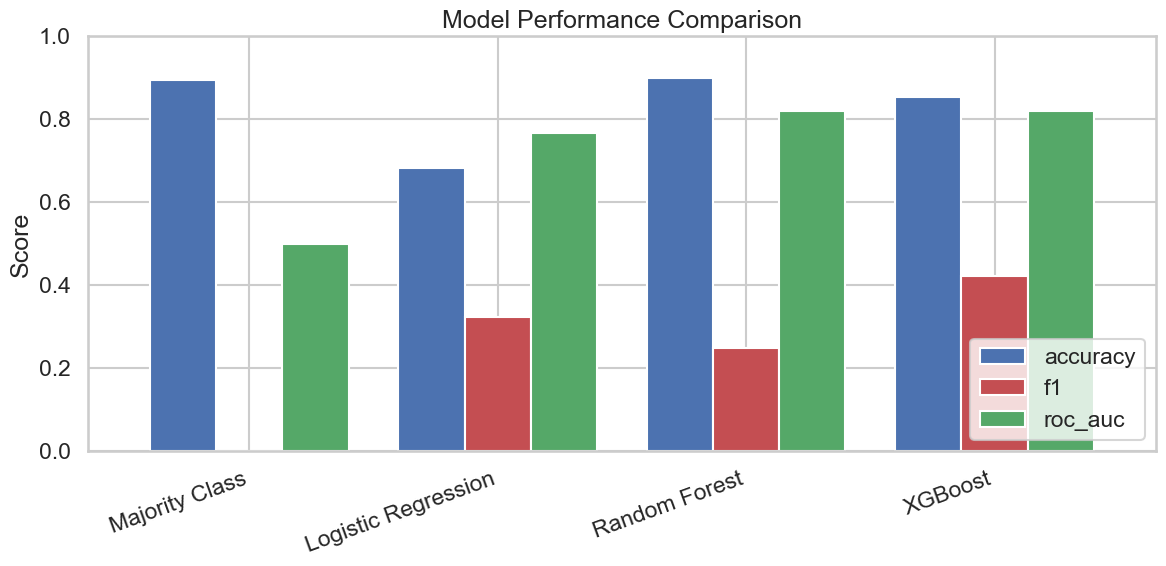

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))
res_df[["accuracy", "f1", "roc_auc"]].plot.bar(
    ax=ax, width=0.8, color=["#4C72B0", "#C44E52", "#55A868"])
ax.set_ylabel("Score"); ax.set_ylim(0, 1.0); ax.set_title("Model Performance Comparison")
ax.set_xticklabels(res_df.index, rotation=20, ha="right"); ax.legend(loc="lower right")
fig.tight_layout(); fig.savefig("figures/05_model_comparison.png", dpi=150); plt.show()

### 5.2 ROC and Precision-Recall curves

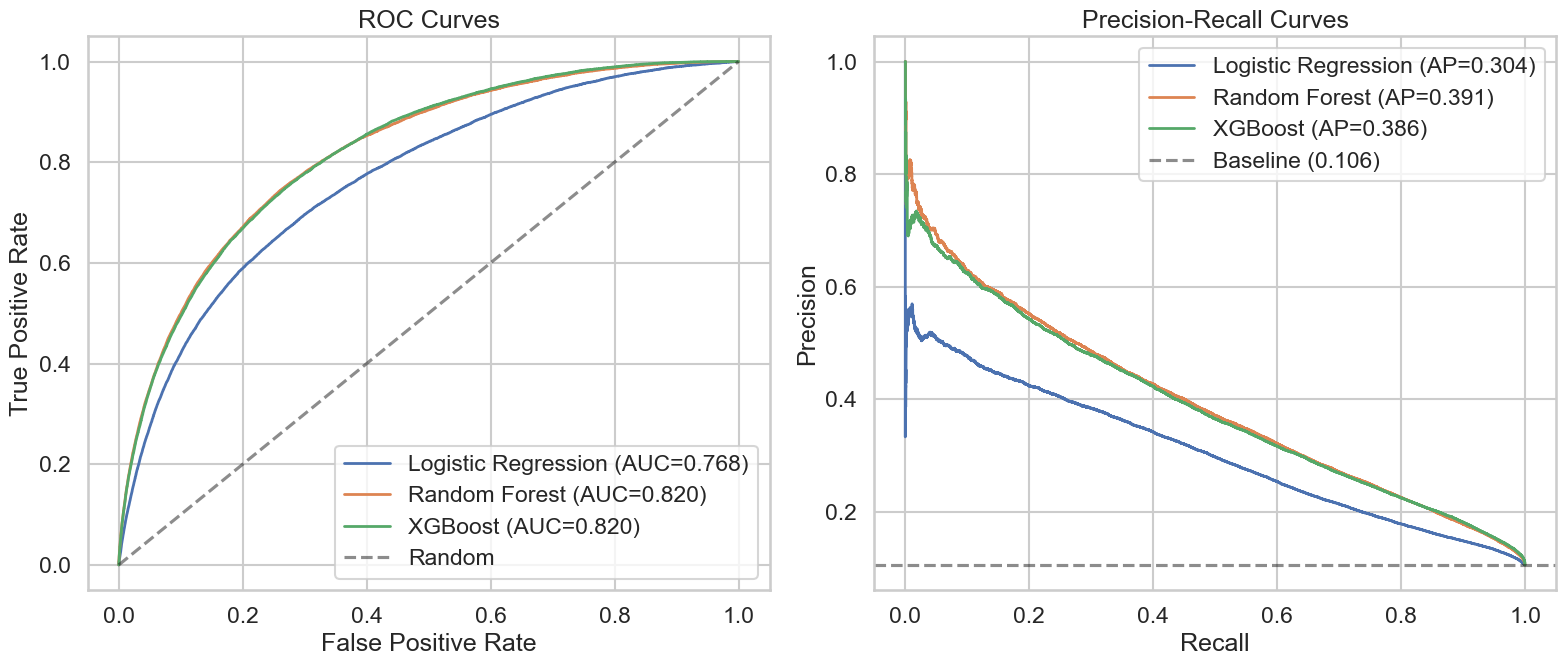

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for name, prob in [("Logistic Regression", lprob), ("Random Forest", rprob), ("XGBoost", xprob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc_score(y_test, prob):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
axes[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curves")
axes[0].legend(loc="lower right")

for name, prob in [("Logistic Regression", lprob), ("Random Forest", rprob), ("XGBoost", xprob)]:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    axes[1].plot(rec, prec, lw=2, label=f"{name} (AP={average_precision_score(y_test, prob):.3f})")
axes[1].axhline(y_test.mean(), color="k", ls="--", alpha=0.5, label=f"Baseline ({y_test.mean():.3f})")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curves")
axes[1].legend(loc="upper right")
fig.tight_layout()
fig.savefig("figures/06_roc_curves.png", dpi=150)
fig.savefig("figures/07_pr_curves.png", dpi=150); plt.show()

### 5.3 Confusion matrix (best model by F1)

Best model by F1: XGBoost
              precision    recall  f1-score   support

     Non-hit       0.94      0.90      0.92    207382
         Hit       0.37      0.50      0.42     24571

    accuracy                           0.85    231953
   macro avg       0.65      0.70      0.67    231953
weighted avg       0.88      0.85      0.86    231953



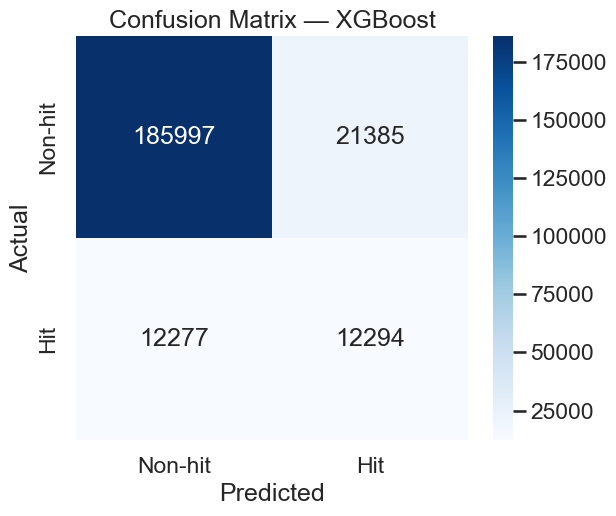

In [19]:
best_name = res_df["f1"].idxmax()
best_pred = {"Random Forest": (rprob >= rf_t).astype(int),
             "XGBoost": xp, "Logistic Regression": logit.predict(X_test)}[best_name]
results["best_model"] = best_name
print("Best model by F1:", best_name)
print(classification_report(y_test, best_pred, target_names=["Non-hit", "Hit"]))

cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Non-hit", "Hit"], yticklabels=["Non-hit", "Hit"])
ax.set(xlabel="Predicted", ylabel="Actual", title=f"Confusion Matrix — {best_name}")
fig.tight_layout(); fig.savefig("figures/08_confusion_best.png", dpi=150); plt.show()

### 5.4 Which audio characteristics drive hits?

This is the direct answer to the research question.

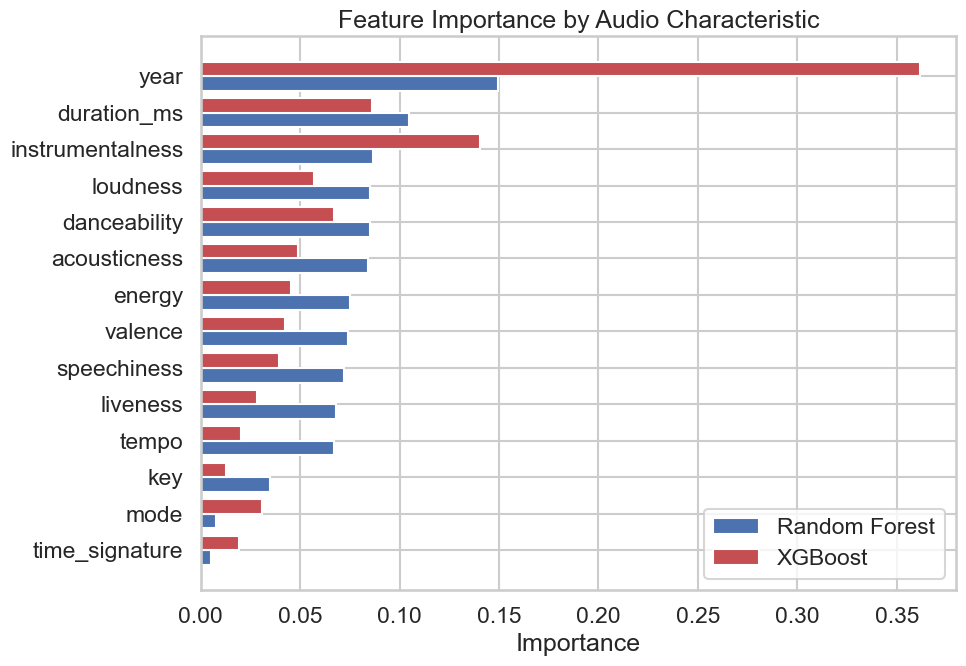

,feature,rf_importance,xgb_importance
13,year,0.1494,0.3616
7,instrumentalness,0.0865,0.1405
11,duration_ms,0.1048,0.0861
0,danceability,0.0852,0.0672
3,loudness,0.0854,0.0571
6,acousticness,0.0843,0.0490
1,energy,0.0750,0.0452
9,valence,0.0742,0.0423
5,speechiness,0.0719,0.0394
4,mode,0.0080,0.0308


In [20]:
imp = pd.DataFrame({
    "feature": FEATURES,
    "rf_importance": rf.feature_importances_,
    "xgb_importance": xgb_clf.feature_importances_,
}).sort_values("xgb_importance", ascending=False)
imp.to_csv("figures/table_feature_importance.csv", index=False)

order = imp.sort_values("rf_importance")
y_pos = np.arange(len(order))
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(y_pos - 0.2, order["rf_importance"], height=0.4, label="Random Forest", color="#4C72B0")
ax.barh(y_pos + 0.2, order["xgb_importance"], height=0.4, label="XGBoost", color="#C44E52")
ax.set_yticks(y_pos); ax.set_yticklabels(order["feature"])
ax.set(xlabel="Importance", title="Feature Importance by Audio Characteristic"); ax.legend()
fig.tight_layout(); fig.savefig("figures/09_feature_importance.png", dpi=150); plt.show()
imp.round(4)

### 5.5 Ablation study

We dropped the three most important features and retrained XGBoost. A large F1 drop
confirmed that those audio characteristics carried most of the predictive signal.

In [21]:
ablation = {"full": f1_score(y_test, xp)}
top3 = imp["feature"].head(3).tolist()
xgb_ab = xgb.XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, scale_pos_weight=scale_pos, eval_metric="logloss",
    tree_method="hist", n_jobs=-1, random_state=RNG)
xgb_ab.fit(X_train.drop(columns=top3), y_train)
ab_prob = xgb_ab.predict_proba(X_test.drop(columns=top3))[:, 1]
ab_t = best_threshold(y_train, xgb_ab.predict_proba(X_train.drop(columns=top3))[:, 1])
ablation[f"drop_top3 ({', '.join(top3)})"] = f1_score(y_test, (ab_prob >= ab_t).astype(int))
results["ablation"] = {k: float(v) for k, v in ablation.items()}
pd.Series(ablation).round(4)

full                                               0.4221
drop_top3 (year, instrumentalness, duration_ms)    0.3316
dtype: float64

### 5.6 Save all metrics

In [22]:
with open("figures/metrics.json", "w") as f:
    json.dump(results, f, indent=2)
print("Saved figures, tables, and metrics.json to ./figures/")
print("Best model by F1:", results["best_model"])

Saved figures, tables, and metrics.json to ./figures/
Best model by F1: XGBoost


---
### Takeaways 
- Both tree ensembles beat the majority-class floor and logistic regression on F1/PR-AUC.
- The most predictive audio characteristics are **{top features from §5.4}**.
- Predicting hits from audio alone remains hard (moderate PR-AUC), consistent with the
  Hit Song Science literature — audio explains part, but not all, of popularity.